In [99]:
import numpy as np
import matplotlib.pyplot as plt
import xsimlab as xs

In [100]:
@xs.process
class Geometry:
    '''
    Process to create geometrical parameters needed by the model from the grid shape and size
    '''
    shape = xs.variable(dims="ny_nx", intent='in', description="nb. of grid nodes in the y- and x-directions")
    length = xs.variable(dims="ny_nx", intent='in')
    
    spacing = xs.variable(dims="ny_nx", intent='out')
    
    x = xs.index(dims="x")
    y = xs.index(dims="y")
    
    def initialize(self):
        self.spacing = self.length/(self.shape - 1)
        self.x = np.linspace(0, self.length[1], self.shape[1])
        self.y = np.linspace(0, self.length[0], self.shape[0])
        

In [92]:
@xs.process
class BoundaryCondition:
    mask = xs.variable(dims=("y","x"), intent='in')

In [93]:
@xs.process
class Topography:
    elevation = xs.variable(dims=("y","x"), intent='inout')
    surface_up = xs.group('surf_up')
    surface_down = xs.group('surf_down')
    
    def finalize_step(self):
        surface_down_sum = sum((dtopo for dtopo in self.surface_down))
        surface_up_sum = sum((dtopo for dtopo in self.surface_up))
        self.elevation = self.elevation + surface_down_sum + surface_up_sum

In [94]:
@xs.process
class Uplift:
    rate = xs.variable(intent='in')
    mask = xs.foreign(BoundaryCondition, 'mask')
    surface_up = xs.variable(dims=("y","x"), intent='out', groups='surf_up')
    
    @xs.runtime(args='step_delta')
    def run_step(self, dt):
        self.surface_up = np.where(self.mask, self.rate*dt, 0)
        

In [95]:
@xs.process
class Diffusion:
    diffusivity = xs.variable(intent='in')
    mask = xs.foreign(BoundaryCondition, 'mask')
    spacing = xs.foreign(Geometry, 'spacing')
    surface_down = xs.variable(dims=("y","x"), intent='out', groups='surf_down')
    h = xs.foreign(Topography, 'elevation')
    
    @xs.runtime(args='step_delta')
    def run_step(self, dt):
        self.surface_down = np.where(self.mask,
                                     self.diffusivity*dt*(
                          (np.roll(self.h,1,axis=1)-2*self.h+np.roll(self.h,-1,axis=1))/self.spacing[1]**2 
                        + (np.roll(self.h,1,axis=0)-2*self.h+np.roll(self.h,-1,axis=0))/self.spacing[0]**2
                                                           ),
                                     0)
                                     

In [96]:
model = xs.Model({'grid':Geometry, 'base_level':BoundaryCondition, 'topography':Topography,
                 'uplift':Uplift, 'diffusion':Diffusion})

In [98]:
model.grid

<Geometry 'grid' (xsimlab process)>
Variables:
    shape       [in] ('ny_nx',) nb. of grid nodes in the y- and x-d...
    length      [in] ('ny_nx',) 
    spacing    [out] ('ny_nx',) 
    x          [out] ('x',) 
    y          [out] ('y',) 
Simulation stages:
    initialize

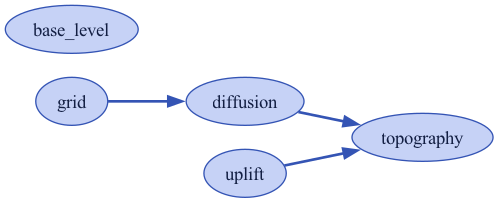

In [57]:
model.visualize()

In [58]:
%load_ext xsimlab.ipython

The xsimlab.ipython extension is already loaded. To reload it, use:
  %reload_ext xsimlab.ipython


In [59]:
nx = 201
ny = 101
h = np.zeros((ny,nx))
mask = np.ones_like(h, dtype=bool)

xsin = np.linspace(0,nx-1,nx).astype(int)
nmeanders = 2
amplitude = ny/4
ysin = (np.sin(2*np.pi*xsin/nx*nmeanders)*amplitude + ny/2 +1).astype(int)

mask[ysin,xsin] = False

In [60]:
# %create_setup model
import xsimlab as xs
import xarray as xr

ds_in = xs.create_setup(
    model=model,
    clocks={'tstep':np.linspace(0,1e5,1001),
           'time':np.linspace(0,1e5,11)},
    master_clock = 'tstep',
    input_vars={
        'grid__shape': [ny,nx],
        'grid__length': [1000,2000],
        'base_level__mask': xr.DataArray(mask, dims=('y','x')),
        'topography__elevation': xr.DataArray(h, dims=('y','x')),
        'uplift__rate': 1e-4,
        'diffusion__diffusivity': 1e-2,
    },
    output_vars={'topography__elevation':'time'}
)


In [61]:
ds_in

<xarray.Dataset>
Dimensions:                 (tstep: 1001, time: 11, ny_nx: 2, y: 101, x: 201)
Coordinates:
  * tstep                   (tstep) float64 0.0 100.0 200.0 ... 9.99e+04 1e+05
  * time                    (time) float64 0.0 1e+04 2e+04 ... 8e+04 9e+04 1e+05
Dimensions without coordinates: ny_nx, y, x
Data variables:
    grid__shape             (ny_nx) int64 101 201
    grid__length            (ny_nx) int64 1000 2000
    base_level__mask        (y, x) bool True True True True ... True True True
    topography__elevation   (y, x) float64 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    uplift__rate            float64 0.0001
    diffusion__diffusivity  float64 0.01

In [63]:
ds_out = ds_in.xsimlab.run(model=model)

In [64]:
ds_out

<xarray.Dataset>
Dimensions:                 (y: 101, x: 201, ny_nx: 2, time: 11, tstep: 1001)
Coordinates:
  * time                    (time) float64 0.0 1e+04 2e+04 ... 8e+04 9e+04 1e+05
  * tstep                   (tstep) float64 0.0 100.0 200.0 ... 9.99e+04 1e+05
  * x                       (x) float64 0.0 10.0 20.0 ... 1.99e+03 2e+03
  * y                       (y) float64 0.0 10.0 20.0 30.0 ... 980.0 990.0 1e+03
Dimensions without coordinates: ny_nx
Data variables:
    base_level__mask        (y, x) bool True True True True ... True True True
    diffusion__diffusivity  float64 0.01
    grid__length            (ny_nx) int64 1000 2000
    grid__shape             (ny_nx) int64 101 201
    topography__elevation   (time, y, x) float64 0.0 0.0 0.0 ... 10.0 10.0 10.0
    uplift__rate            float64 0.0001

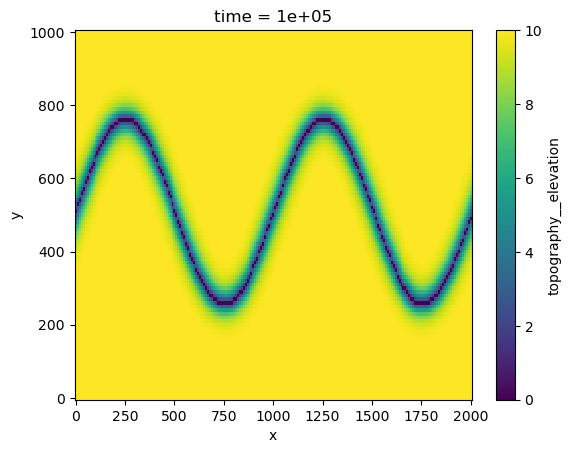

In [71]:
ds_out.topography__elevation.isel(time=-1).plot();

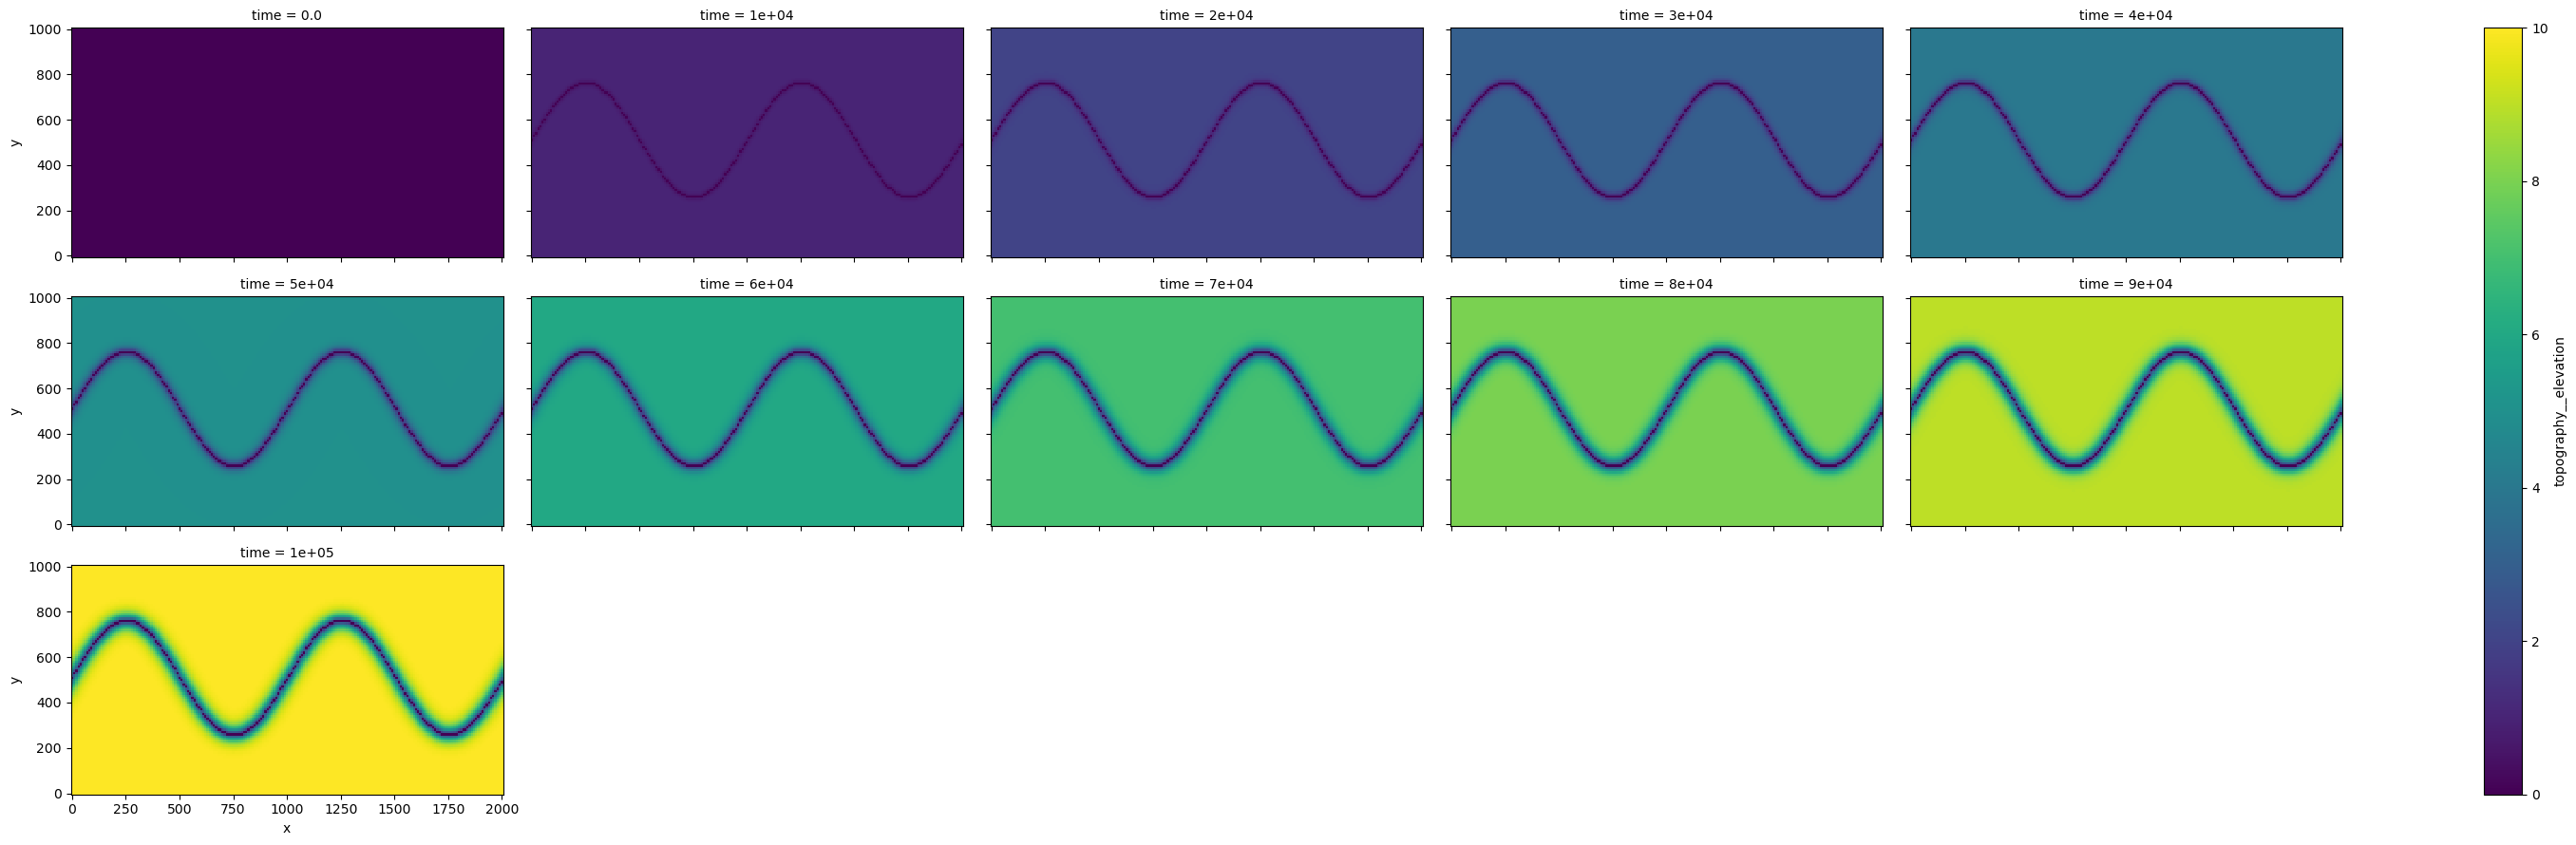

In [74]:
ds_out.topography__elevation.plot(col='time',col_wrap=5, aspect=2)

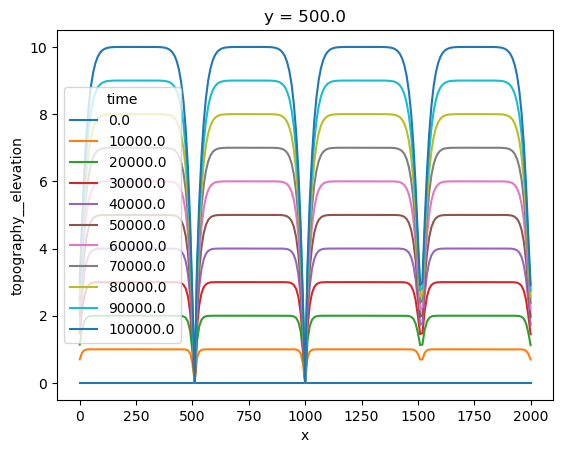

In [77]:
ds_out.topography__elevation.sel(y=500).plot.line(x='x');

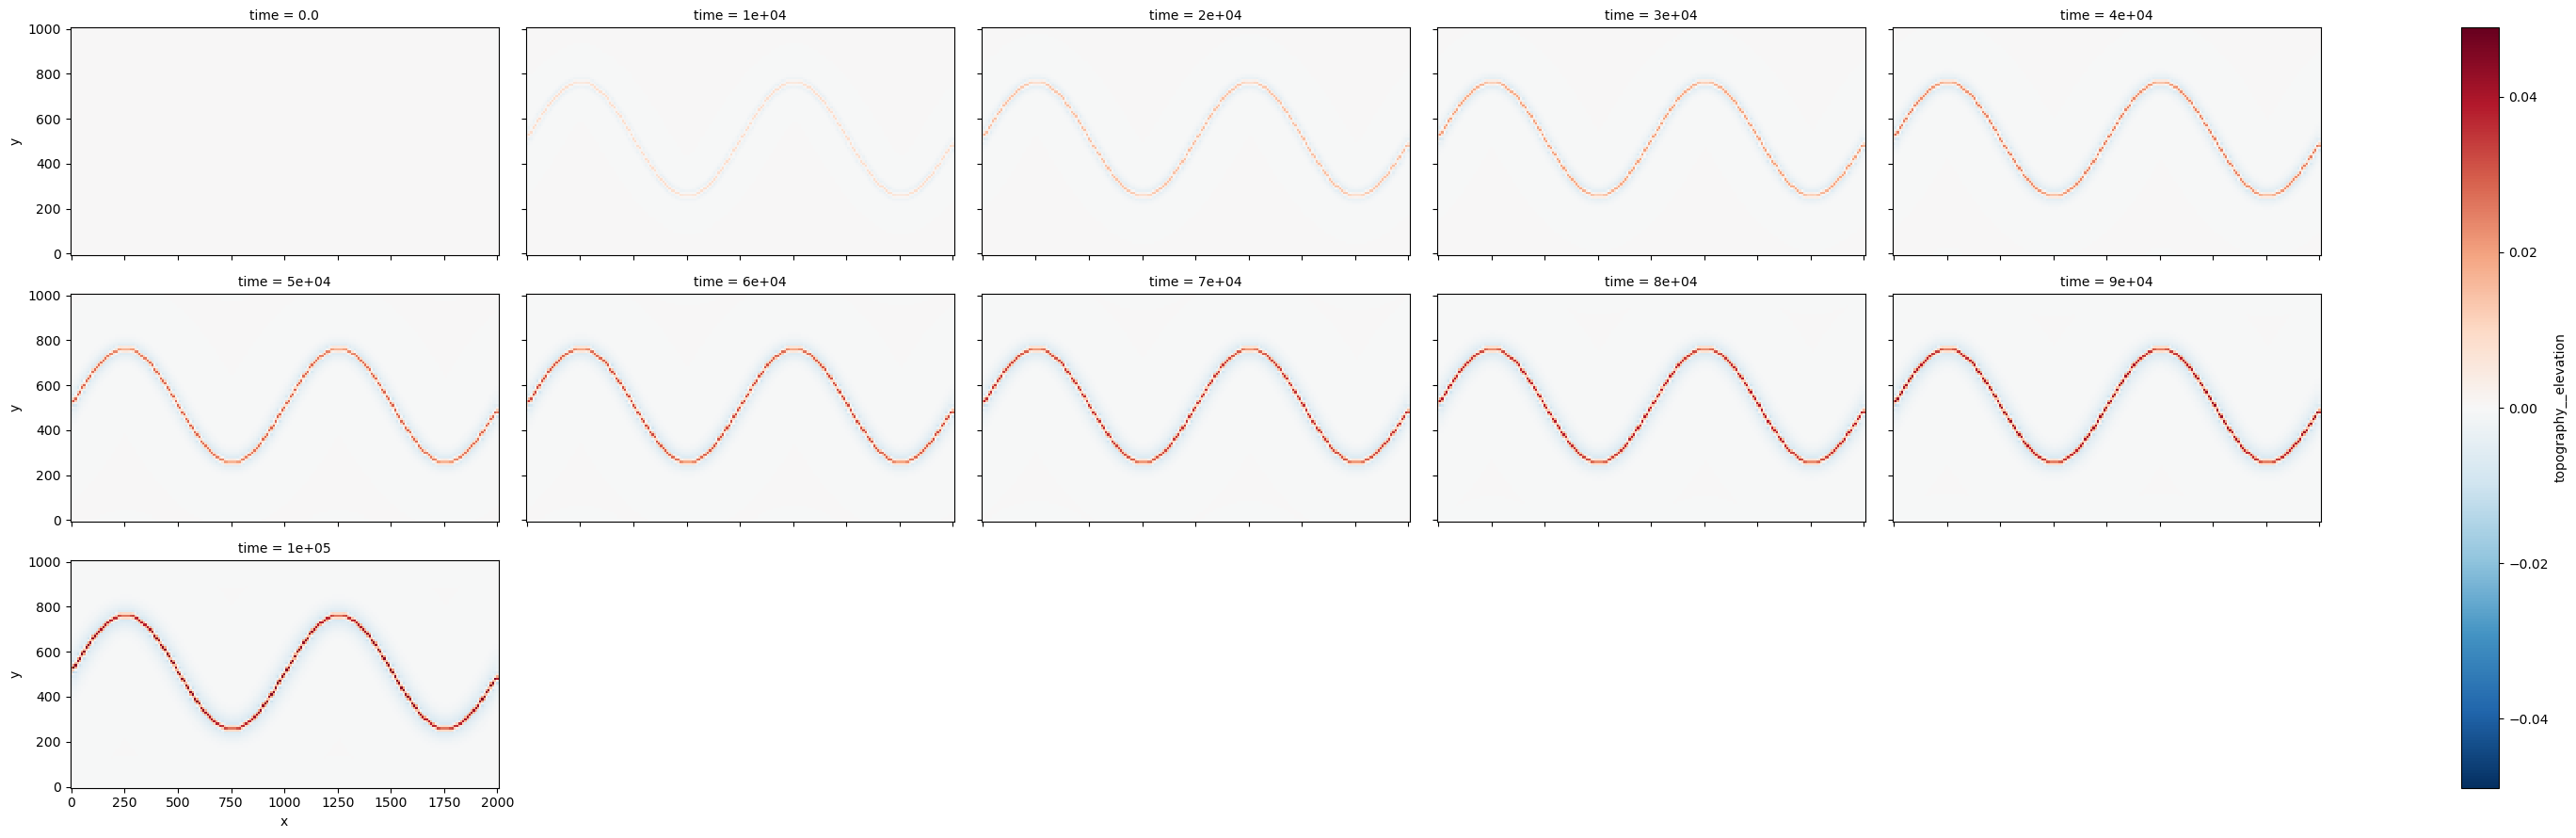

In [80]:
(ds_out.topography__elevation.differentiate('x').differentiate('x') 
 +ds_out.topography__elevation.differentiate('y').differentiate('y')).plot(col='time',aspect=2, col_wrap=5);

In [89]:
# %create_setup model -v
import xsimlab as xs

ds_in = xs.create_setup(
    model=model,
    clocks={},
    input_vars={
        # nb. of grid nodes in the y- and x-directions
        'grid__shape': ,
        # ---
        'grid__length': ,
        # ---
        'base_level__mask': ,
        # ---
        'topography__elevation': ,
        # ---
        'uplift__rate': ,
        # ---
        'diffusion__diffusivity': ,
    },
    output_vars={}
)
